In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_moons, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

data = pd.read_csv('data/kyle_schwarber_full_data.csv')
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'home_run'])
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]
data = data.dropna()

In [2]:
X = pd.DataFrame(data.drop(columns=['hits']))
y = pd.Series(data['hits'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

model.fit(X_train, y_train)


# RBF_SVM = SVC(kernel='rbf', C=1.0, gamma='scale')
# RBF_SVM.fit(X_train, y_train)

# Test Accuracy
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_pred, y_test)
print(test_accuracy)

0.9554910498306725


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(kernel='rbf', C=0.05, gamma='scale', probability=True))
])

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)[:,1]

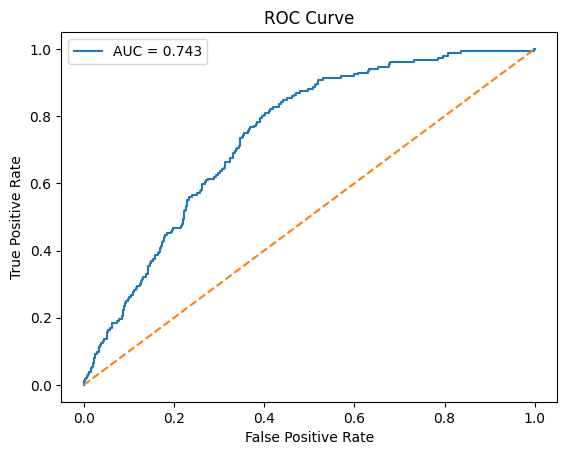

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
# Permutation Importance:

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=307, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

print(perm_df)

             feature  importance
0               zone    0.210343
4  release_spin_rate    0.007225
2        pitch_count    0.007030
6         pitch_name    0.006494
5       pitch_number   -0.000293
1           p_throws   -0.003256
3    effective_speed   -0.005862
